In [1]:
import sys
import importlib.metadata as md

print("Python:", sys.version)
print("Executable:", sys.executable)

packages = ["numpy", "tensorflow", "deepchem", "rdkit"]

for package in packages:
    try:
        print(f"{package}: {md.version(package)}")
    except md.PackageNotFoundError:
        print(f"{package}: BELUM TERINSTAL")

Python: 3.10.12 (main, Nov 20 2023, 15:14:05) [GCC 11.4.0]
Executable: /usr/bin/python
numpy: 1.26.4
tensorflow: 2.21.0
deepchem: 2.8.1.dev20260821122258
rdkit: 2026.3.6


In [2]:
import numpy as np
import tensorflow as tf
import deepchem as dc

from deepchem.models import GraphConvModel

print("Semua library berhasil diimport!")

graph_conv = GraphConvModel(
    n_tasks=1,
    batch_size=10,
    mode="regression",
    learning_rate=0.001,
    batch_normalize=False
)

print("GraphConvModel berhasil dibuat!")

I0000 00:00:1791431984.410805     545 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading material featurizer, missing a dependency. No module named 'ase'


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading some PyTorch models, missing a dependency. No module named 'transformers'
No module named 'transformers'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'transformers'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'


Semua library berhasil diimport!
GraphConvModel berhasil dibuat!


In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/aliyarahmaazizah/USP5/main/USP5_1.csv"

df = pd.read_csv(url)

print("Jumlah data:", len(df))
print("Kolom dataset:", df.columns.tolist())

display(df.head())

Jumlah data: 118
Kolom dataset: ['Molecule ChEMBL ID', 'Smiles', 'pIC50']


,Molecule ChEMBL ID,Smiles,pIC50
0,CHEMBL5285743,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(N3C(=O)Cc4cc...,3.886057
1,CHEMBL4451435,O=C(O)CCc1nnc(-c2ccc(Cl)cc2)o1,3.346787
2,CHEMBL5267683,O=C(NCCc1ccc(Cl)cc1)c1ccc2nc3c(c(Cl)c2c1)CCCC3,3.698970
3,CHEMBL5290717,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(N3CCOCC3)CC2...,4.346787
4,CHEMBL5285627,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(c3ccc(F)cc3)...,4.638272


In [4]:
import deepchem as dc

loader = dc.data.CSVLoader(
    tasks=["pIC50"],
    smiles_field="Smiles",
    featurizer=dc.feat.ConvMolFeaturizer()
)

dataset = loader.create_dataset(url)

print("Jumlah data:", len(dataset))
print("Shape y:", dataset.y.shape)
print("Shape w:", dataset.w.shape)

smiles_field is deprecated and will be removed in a future version of DeepChem.Use feature_field instead.
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:

Jumlah data: 118
Shape y: (118, 1)
Shape w: (118, 1)


[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:01:41] DEPRECATIO

In [5]:
import deepchem as dc
import numpy as np
import tensorflow as tf

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

splitter = dc.splits.RandomSplitter()

train, valid, test = splitter.train_valid_test_split(
    dataset,
    frac_train=0.70,
    frac_valid=0.29,
    frac_test=0.01,
    seed=SEED
)

print("=" * 50)
print("DATA SPLIT")
print("=" * 50)

print("Training data   :", len(train))
print("Validation data :", len(valid))
print("Testing data    :", len(test))

DATA SPLIT
Training data   : 82
Validation data : 34
Testing data    : 2


In [6]:
from deepchem.models import GraphConvModel

graph_conv = GraphConvModel(
    n_tasks=1,
    batch_size=10,
    mode="regression",
    learning_rate=0.001,
    batch_normalize=False
)

print("Memulai training...")

loss = graph_conv.fit(
    train,
    nb_epoch=10
)

print("Training berhasil!")
print("Loss:", loss)

Memulai training...


W0000 00:00:1791432217.598810     693 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1791432217.649160     545 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


ImportError: `keras.optimizers.legacy` is not supported in Keras 3. When using `tf.keras`, to continue using a `tf.keras.optimizers.legacy` optimizer, you can install the `tf_keras` package (Keras 2) and set the environment variable `TF_USE_LEGACY_KERAS=True` to configure TensorFlow to use `tf_keras` when accessing `tf.keras`.

In [7]:
import importlib.metadata as md

try:
    print("tf_keras:", md.version("tf_keras"))
except md.PackageNotFoundError:
    print("tf_keras belum terinstal")

tf_keras belum terinstal


In [8]:
%pip install "tf-keras==2.21.0"

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 545.8 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 3.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 14.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
cudf 23.12.0 requires numpy<1.25,>=1.21, but you have numpy 2.2.6 which is incompatible.
cudf 23.12.0 requires pandas<1.6.0dev0,>=1.3, but you have pandas 2.3.3 which is incompatible.
cudf 23.12.0 requires protobuf<5,>=4.21, but you have protobuf

In [1]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import deepchem as dc

print("TensorFlow:", tf.__version__)
print("DeepChem:", dc.__version__)
print("Legacy Adam:", tf.keras.optimizers.legacy.Adam)

I0000 00:00:1791432365.411196     868 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.10/dist-packages/tensorflow/python/keras/engine/training_arrays_v1.py:37: UserWarning: A NumPy version >=1.22.4 and <1.29.0 is required for this version of SciPy (detected version 2.2.6)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to 

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/usr/local/lib/python3.10/dist-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/usr/local/lib/python3.10/dist-packages/traitlets/config/application.py", line 1043, in launch_instance
    app.start()
  File "/usr/local/lib/python3.10/dist-packages/ipykernel/kernelapp.p

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/usr/local/lib/python3.10/dist-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/usr/local/lib/python3.10/dist-packages/traitlets/config/application.py", line 1043, in launch_instance
    app.start()
  File "/usr/local/lib/python3.10/dist-packages/ipykernel/kernelapp.p

...


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/usr/local/lib/python3.10/dist-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/usr/local/lib/python3.10/dist-packages/traitlets/config/application.py", line 1043, in launch_instance
    app.start()
  File "/usr/local/lib/python3.10/dist-packages/ipykernel/kernelapp.p

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/usr/local/lib/python3.10/dist-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/usr/local/lib/python3.10/dist-packages/traitlets/config/application.py", line 1043, in launch_instance
    app.start()
  File "/usr/local/lib/python3.10/dist-packages/ipykernel/kernelapp.p

AttributeError: _ARRAY_API not found

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [2]:
%pip install --force-reinstall --no-deps numpy==1.26.4

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 443.9 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 7.5 MB/s eta 0:00:0000:01m00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6

[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import scipy
import tensorflow as tf
import deepchem as dc

from deepchem.models import GraphConvModel

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("TensorFlow:", tf.__version__)
print("DeepChem:", dc.__version__)

print("Legacy Adam:", tf.keras.optimizers.legacy.Adam)

print("Semua library berhasil diimport!")

I0000 00:00:1791432621.050575    1022 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading material featurizer, missing a dependency. No module named 'ase'


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading some PyTorch models, missing a dependency. No module named 'transformers'
No module named 'transformers'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'transformers'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'


NumPy: 1.26.4
SciPy: 1.12.0
TensorFlow: 2.21.0
DeepChem: 2.8.1.dev
Legacy Adam: <class 'tf_keras.src.optimizers.legacy.adam.Adam'>
Semua library berhasil diimport!


In [2]:
import pandas as pd
import deepchem as dc

url = "https://raw.githubusercontent.com/aliyarahmaazizah/USP5/main/USP5_1.csv"

df = pd.read_csv(url)
df.to_csv("USP5_1.csv", index=False)

loader = dc.data.CSVLoader(
    tasks=["pIC50"],
    smiles_field="Smiles",
    featurizer=dc.feat.ConvMolFeaturizer()
)

dataset = loader.create_dataset("USP5_1.csv")

splitter = dc.splits.RandomSplitter()

train, valid, test = splitter.train_valid_test_split(
    dataset,
    frac_train=0.70,
    frac_valid=0.29,
    frac_test=0.01,
    seed=42
)

print("Total data:", len(dataset))
print("Training:", len(train))
print("Validation:", len(valid))
print("Testing:", len(test))

smiles_field is deprecated and will be removed in a future version of DeepChem.Use feature_field instead.
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:

Total data: 118
Training: 82
Validation: 34
Testing: 2


[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:11:20] DEPRECATIO

In [3]:
from deepchem.models import GraphConvModel

graph_conv = GraphConvModel(
    n_tasks=1,
    batch_size=10,
    mode="regression",
    learning_rate=0.001,
    batch_normalize=False
)

print("=" * 50)
print("TRAINING GRAPHCONVMODEL")
print("=" * 50)

print("Memulai training 10 epoch...")

loss = graph_conv.fit(
    train,
    nb_epoch=10
)

print("\nTraining berhasil!")
print("Loss:", loss)

W0000 00:00:1791432788.378996    1170 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1791432788.429840    1022 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


TRAINING GRAPHCONVMODEL
Memulai training 10 epoch...

Training berhasil!
Loss: 2.1823684692382814


In [4]:
print("=" * 50)
print("TRAINING GRAPHCONVMODEL")
print("=" * 50)

print("Melanjutkan training 990 epoch...")

loss = graph_conv.fit(
    train,
    nb_epoch=990
)

print("\nTraining 1000 epoch selesai!")
print("Final Loss:", loss)

TRAINING GRAPHCONVMODEL
Melanjutkan training 990 epoch...

Training 1000 epoch selesai!
Final Loss: 0.10959593772888183


In [5]:
metric = dc.metrics.Metric(
    dc.metrics.pearson_r2_score
)

train_scores = graph_conv.evaluate(
    train,
    [metric]
)

valid_scores = graph_conv.evaluate(
    valid,
    [metric]
)

print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

print("Train Scores:", train_scores)
print("Validation Scores:", valid_scores)

MODEL EVALUATION
Train Scores: {'pearson_r2_score': 0.9351344061594686}
Validation Scores: {'pearson_r2_score': 0.7258412268057262}


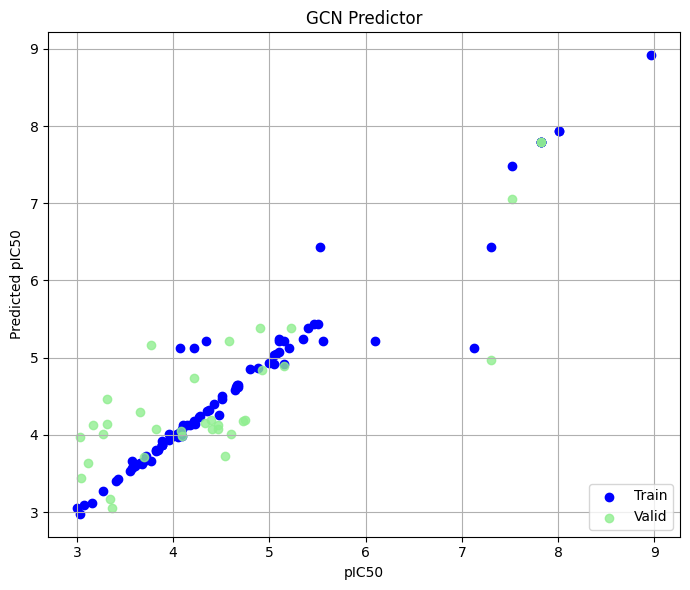

Grafik berhasil dibuat!
File tersimpan: GCN_Predictor.png


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. PREDICTION
# ==========================================

pred_train = graph_conv.predict(train)
pred_valid = graph_conv.predict(valid)

y_train = np.asarray(train.y, dtype=np.float32).reshape(-1)
y_valid = np.asarray(valid.y, dtype=np.float32).reshape(-1)

pred_train = np.asarray(pred_train, dtype=np.float32).reshape(-1)
pred_valid = np.asarray(pred_valid, dtype=np.float32).reshape(-1)

# ==========================================
# 2. SAVE PREDICTIONS
# ==========================================

train_result = pd.DataFrame({
    "Smiles": train.ids,
    "Measured_pIC50": y_train,
    "Predicted_pIC50": pred_train
})

valid_result = pd.DataFrame({
    "Smiles": valid.ids,
    "Measured_pIC50": y_valid,
    "Predicted_pIC50": pred_valid
})

train_result.to_csv("train_predictions.csv", index=False)
valid_result.to_csv("validation_predictions.csv", index=False)

# ==========================================
# 3. PLOT GCN PREDICTOR
# ==========================================

plt.figure(figsize=(7, 6))

plt.scatter(
    y_train,
    pred_train,
    label="Train",
    c="blue"
)

plt.scatter(
    y_valid,
    pred_valid,
    c="lightgreen",
    label="Valid",
    alpha=0.8
)

plt.title("GCN Predictor")
plt.xlabel("pIC50")
plt.ylabel("Predicted pIC50")

plt.legend(loc=4)
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "GCN_Predictor.png",
    dpi=200
)

plt.show()

print("Grafik berhasil dibuat!")
print("File tersimpan: GCN_Predictor.png")

In [7]:
import os

model_dir = graph_conv.model_dir

graph_conv.save_checkpoint()

print("Model berhasil disimpan!")
print("Lokasi model:", model_dir)

Model berhasil disimpan!
Lokasi model: /tmp/tmpuloy1jbg


In [8]:
import os
import shutil

folder_tujuan = os.path.abspath("graphconv_saved_model")

shutil.copytree(
    graph_conv.model_dir,
    folder_tujuan,
    dirs_exist_ok=True
)

print("Checkpoint tersimpan di:", folder_tujuan)

Checkpoint tersimpan di: /data/Aliya/graphconv_saved_model


In [9]:
print("Model:", type(graph_conv).__name__)
print("Checkpoint:", graph_conv.model_dir)

Model: GraphConvModel
Checkpoint: /tmp/tmpuloy1jbg


In [10]:
import numpy as np
import pandas as pd
import deepchem as dc
from rdkit import Chem

# 1. Validasi struktur SMILES
mols = [Chem.MolFromSmiles(s) for s in smiles]

invalid = [
    i + 1
    for i, mol in enumerate(mols)
    if mol is None
]

if invalid:
    raise ValueError(
        f"SMILES tidak valid pada nomor: {invalid}"
    )

print("Semua SMILES berhasil divalidasi!")

# 2. Featurization
featurizer = dc.feat.ConvMolFeaturizer()
x = featurizer.featurize(mols)

# 3. Prediksi menggunakan model yang sudah dilatih
predicted_pIC50 = graph_conv.predict_on_batch(x)
predicted_pIC50 = np.asarray(predicted_pIC50).reshape(-1)

# 4. Simpan hasil
result = pd.DataFrame({
    "Compound": [
        f"Compound {i}"
        for i in range(1, len(smiles) + 1)
    ],
    "SMILES": smiles,
    "Predicted_pIC50": predicted_pIC50
})

result.to_csv(
    "predicted_new_compounds.csv",
    index=False
)

display(result)

print("Prediksi berhasil!")
print("Hasil tersimpan: predicted_new_compounds.csv")

NameError: name 'smiles' is not defined

In [11]:
# ==========================================
# DAFTAR 14 SENYAWA BARU
# ==========================================

smiles = [
    'O=C(CC(/C=C/C1=CC=C(O)C(O)=C1)=O)/C=C/C2=CC(OC)=C(O)C=C2',

    'O=C(CC(/C=C/C1=CC=C(O)C(O)=C1)=O)/C=C/C2=CC(OC(O)=O)=C(O)C=C2',

    'O=C(CC(/C=C/C1=CC=C(O)C(O)=C1)=O)/C=C/C2=CC(Br)=C(O)C=C2',

    'O=C(CC(/C=C/C1=CC=C(O)C(OC)=C1)=O)/C=C/C2=CC(OC(O)=O)=C(O)C=C2',

    'O=C(CC(/C=C/C1=CC=C(O)C(OC)=C1)=O)/C=C/C2=CC(Br)=C(O)C=C2',

    'O=C(CC(/C=C/C1=CC=C(O)C(Br)=C1)=O)/C=C/C2=CC(OC(O)=O)=C(O)C=C2',

    'O=C(/C(CCC/1)=C/C2=CC(OC)=C(O)C=C2)C1=C\\C3=CC=C(O)C(O)=C3',

    'O=C(/C(CCC/1)=C/C2=CC(OC(O)=O)=C(O)C=C2)C1=C\\C3=CC=C(O)C(O)=C3',

    'O=C(/C(CCC/1)=C/C2=CC(Br)=C(O)C=C2)C1=C\\C3=CC=C(O)C(O)=C3',

    'O=C(/C(CCC/1)=C/C2=CC(OC(O)=O)=C(O)C=C2)C1=C\\C3=CC=C(O)C(OC)=C3',

    'O=C(/C(CCC/1)=C/C2=CC(Br)=C(O)C=C2)C1=C\\C3=CC=C(O)C(OC)=C3',

    'O=C(/C(CCC/1)=C/C2=CC(OC(O)=O)=C(O)C=C2)C1=C\\C3=CC=C(O)C(Br)=C3',

    'O=C(CC(/C=C/C1=CC=C(O)C(OC)=C1)=O)/C=C/C2=CC(OC)=C(O)C=C2',

    'O=C1/C(CCC/C1=C\\C2=CC=C(C(Br)=C2)O)=C/C3=CC(Br)=C(C=C3)O'
]

print("Jumlah senyawa:", len(smiles))

Jumlah senyawa: 14


In [12]:
mols = [Chem.MolFromSmiles(s) for s in smiles]

In [13]:
invalid = [
    i + 1
    for i, mol in enumerate(mols)
    if mol is None
]

if invalid:
    raise ValueError(
        f"SMILES tidak valid pada nomor: {invalid}"
    )

print("Semua SMILES valid!")
print("Jumlah molekul:", len(mols))

Semua SMILES valid!
Jumlah molekul: 14


In [14]:
import numpy as np
import pandas as pd
import deepchem as dc

# Featurization
featurizer = dc.feat.ConvMolFeaturizer()
x = featurizer.featurize(mols)

# Prediksi menggunakan model 1000 epoch
predicted_pIC50 = graph_conv.predict_on_batch(x)
predicted_pIC50 = np.asarray(predicted_pIC50).reshape(-1)

# Membuat tabel hasil
result = pd.DataFrame({
    "Compound": [
        f"Compound {i}"
        for i in range(1, len(smiles) + 1)
    ],
    "SMILES": smiles,
    "Predicted_pIC50": predicted_pIC50
})

# Menyimpan CSV
result.to_csv(
    "predicted_new_compounds.csv",
    index=False
)

print("PREDIKSI pIC50 BERHASIL!")
display(result)

PREDIKSI pIC50 BERHASIL!


[04:25:29] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:25:29] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:25:29] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:25:29] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:25:29] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:25:29] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:25:29] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:25:29] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:25:29] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:25:29] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:25:29] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:25:29] DEPRECATIO

,Compound,SMILES,Predicted_pIC50
0,Compound 1,O=C(CC(/C=C/C1=CC=C(O)C(O)=C1)=O)/C=C/C2=CC(OC...,3.623826
1,Compound 2,O=C(CC(/C=C/C1=CC=C(O)C(O)=C1)=O)/C=C/C2=CC(OC...,3.583220
2,Compound 3,O=C(CC(/C=C/C1=CC=C(O)C(O)=C1)=O)/C=C/C2=CC(Br...,3.414895
3,Compound 4,O=C(CC(/C=C/C1=CC=C(O)C(OC)=C1)=O)/C=C/C2=CC(O...,3.911183
4,Compound 5,O=C(CC(/C=C/C1=CC=C(O)C(OC)=C1)=O)/C=C/C2=CC(B...,3.929881
5,Compound 6,O=C(CC(/C=C/C1=CC=C(O)C(Br)=C1)=O)/C=C/C2=CC(O...,3.808834
6,Compound 7,O=C(/C(CCC/1)=C/C2=CC(OC)=C(O)C=C2)C1=C\C3=CC=...,5.131525
7,Compound 8,O=C(/C(CCC/1)=C/C2=CC(OC(O)=O)=C(O)C=C2)C1=C\C...,5.113186
8,Compound 9,O=C(/C(CCC/1)=C/C2=CC(Br)=C(O)C=C2)C1=C\C3=CC=...,4.652741
9,Compound 10,O=C(/C(CCC/1)=C/C2=CC(OC(O)=O)=C(O)C=C2)C1=C\C...,5.403139


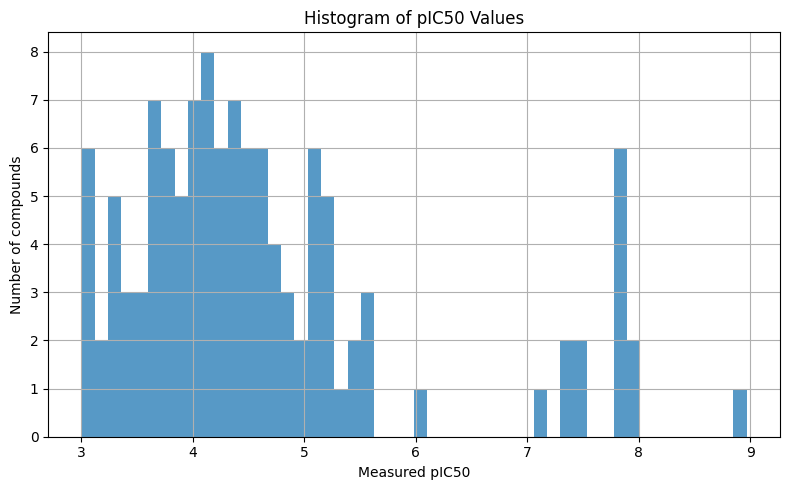

Histogram berhasil dibuat!
File tersimpan: /data/Aliya/pIC50_histogram.png


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv(
    "/data/Aliya/USP5_1.csv"
)

# ==========================================
# 2. PREPARE pIC50 DATA
# ==========================================

pIC50s = pd.to_numeric(
    df["pIC50"],
    errors="coerce"
).dropna()

# ==========================================
# 3. HISTOGRAM
# ==========================================

plt.figure(figsize=(8, 5))

plt.hist(
    pIC50s,
    bins=50,
    alpha=0.75
)

plt.xlabel("Measured pIC50")
plt.ylabel("Number of compounds")
plt.title("Histogram of pIC50 Values")

plt.grid(True)
plt.tight_layout()

# ==========================================
# 4. SAVE HISTOGRAM
# ==========================================

plt.savefig(
    "/data/Aliya/pIC50_histogram.png",
    dpi=200
)

plt.show()

print("Histogram berhasil dibuat!")
print("File tersimpan: /data/Aliya/pIC50_histogram.png")

In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================================
# 1. LOAD PREDICTION RESULTS
# ==========================================

train_df = pd.read_csv("train_predictions.csv")
valid_df = pd.read_csv("validation_predictions.csv")

# ==========================================
# 2. EVALUATION FUNCTION
# ==========================================

def evaluate_model(df, name):
    y_true = df["Measured_pIC50"]
    y_pred = df["Predicted_pIC50"]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Dataset": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# ==========================================
# 3. CALCULATE METRICS
# ==========================================

results = [
    evaluate_model(train_df, "Training"),
    evaluate_model(valid_df, "Validation")
]

evaluation_df = pd.DataFrame(results)

print("=" * 55)
print("GRAPHCONVMODEL PERFORMANCE EVALUATION")
print("=" * 55)

display(evaluation_df.round(4))

# ==========================================
# 4. SAVE EVALUATION
# ==========================================

evaluation_df.to_csv(
    "GCN_evaluation_metrics.csv",
    index=False
)

print("Evaluasi berhasil disimpan!")

GRAPHCONVMODEL PERFORMANCE EVALUATION


,Dataset,MAE,RMSE,R2
0,Training,0.1384,0.3397,0.9346
1,Validation,0.5125,0.6877,0.7239


Evaluasi berhasil disimpan!


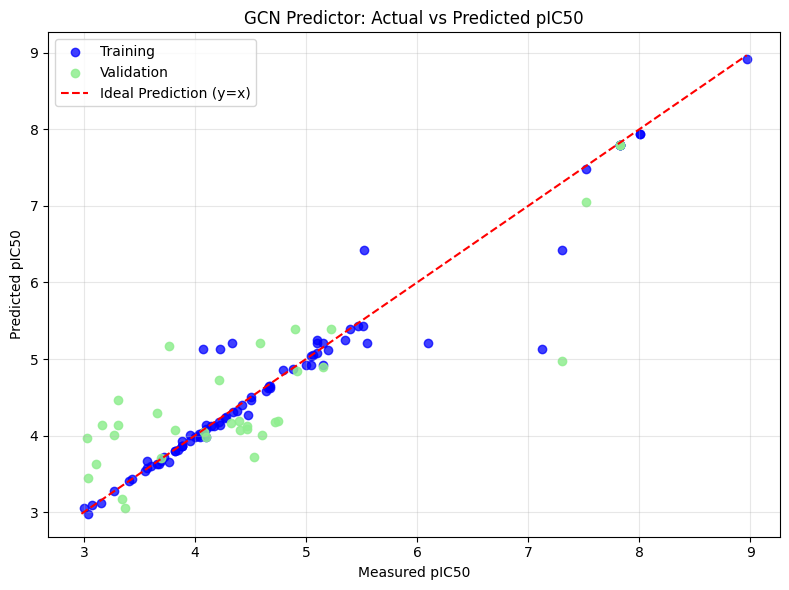

Grafik berhasil disimpan!


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load hasil prediksi
train_df = pd.read_csv("train_predictions.csv")
valid_df = pd.read_csv("validation_predictions.csv")

plt.figure(figsize=(8, 6))

# Training
plt.scatter(
    train_df["Measured_pIC50"],
    train_df["Predicted_pIC50"],
    color="blue",
    label="Training",
    alpha=0.75
)

# Validation
plt.scatter(
    valid_df["Measured_pIC50"],
    valid_df["Predicted_pIC50"],
    color="lightgreen",
    label="Validation",
    alpha=0.85
)

# Garis prediksi ideal
all_values = np.concatenate([
    train_df["Measured_pIC50"].values,
    train_df["Predicted_pIC50"].values,
    valid_df["Measured_pIC50"].values,
    valid_df["Predicted_pIC50"].values
])

minimum = all_values.min()
maximum = all_values.max()

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "r--",
    label="Ideal Prediction (y=x)"
)

plt.xlabel("Measured pIC50")
plt.ylabel("Predicted pIC50")
plt.title("GCN Predictor: Actual vs Predicted pIC50")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "GCN_Predictor_Final.png",
    dpi=300
)

plt.show()

print("Grafik berhasil disimpan!")

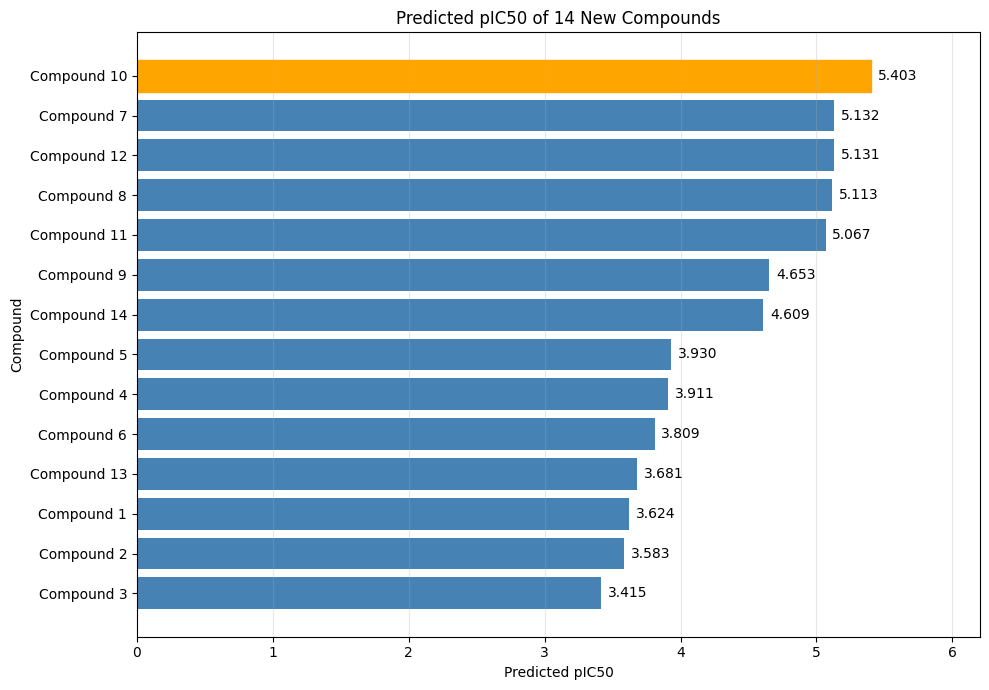

Grafik ranking berhasil disimpan!


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD PREDICTION RESULTS
# ==========================================

df = pd.read_csv("predicted_new_compounds.csv")

# ==========================================
# 2. SORT BY pIC50
# ==========================================

df_sorted = df.sort_values(
    by="Predicted_pIC50",
    ascending=True
)

# ==========================================
# 3. VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 7))

bars = plt.barh(
    df_sorted["Compound"],
    df_sorted["Predicted_pIC50"],
    color="steelblue"
)

# Highlight compound with highest pIC50
bars[-1].set_color("orange")

for bar in bars:
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.3f}",
        va="center"
    )

plt.xlabel("Predicted pIC50")
plt.ylabel("Compound")
plt.title("Predicted pIC50 of 14 New Compounds")

plt.xlim(0, df_sorted["Predicted_pIC50"].max() + 0.8)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

# ==========================================
# 4. SAVE FIGURE
# ==========================================

plt.savefig(
    "GCN_New_Compounds_Ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Grafik ranking berhasil disimpan!")

In [19]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import pandas as pd
import tensorflow as tf
import deepchem as dc

from deepchem.models import GraphConvModel
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================================
# 1. SETTINGS
# ==========================================

SEED = 42
N_FOLDS = 5
EPOCHS = 10
BATCH_SIZE = 10
LEARNING_RATE = 0.001

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ==========================================
# 2. DATASET
# ==========================================

# Menggunakan dataset yang sudah difeaturisasi
cv_dataset = dataset

kf = KFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

results_cv = []

# ==========================================
# 3. CROSS-VALIDATION
# ==========================================

for fold, (train_idx, valid_idx) in enumerate(
    kf.split(np.arange(len(cv_dataset))),
    start=1
):

    print("=" * 50)
    print(f"FOLD {fold}/{N_FOLDS}")
    print("=" * 50)

    # Membuat subset dataset
    train_fold = cv_dataset.select(train_idx)
    valid_fold = cv_dataset.select(valid_idx)

    # Seed untuk inisialisasi model
    np.random.seed(SEED + fold)
    tf.random.set_seed(SEED + fold)

    # Membuat model baru setiap fold
    model_cv = GraphConvModel(
        n_tasks=1,
        batch_size=BATCH_SIZE,
        mode="regression",
        learning_rate=LEARNING_RATE,
        batch_normalize=False
    )

    # Training
    loss = model_cv.fit(
        train_fold,
        nb_epoch=EPOCHS
    )

    # Prediction
    y_true = np.asarray(
        valid_fold.y
    ).reshape(-1)

    y_pred = np.asarray(
        model_cv.predict(valid_fold)
    ).reshape(-1)

    # Evaluation
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    results_cv.append({
        "Fold": fold,
        "Loss": loss,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"Loss : {loss:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

# ==========================================
# 4. RESULTS
# ==========================================

cv_df = pd.DataFrame(results_cv)

print("\n5-FOLD CROSS-VALIDATION RESULTS")
display(cv_df.round(4))

print("\nMEAN PERFORMANCE")
display(
    cv_df[["MAE", "RMSE", "R2"]]
    .agg(["mean", "std"])
    .round(4)
)

# ==========================================
# 5. SAVE RESULTS
# ==========================================

cv_df.to_csv(
    "GCN_5Fold_CrossValidation.csv",
    index=False
)

print("Hasil cross-validation berhasil disimpan!")

FOLD 1/5
Loss : 0.9452
MAE  : 0.6399
RMSE : 0.9422
R2   : 0.4168
FOLD 2/5


Loss : 1.4913
MAE  : 0.7475
RMSE : 0.9453
R2   : 0.5285
FOLD 3/5


Loss : 1.7645
MAE  : 0.9301
RMSE : 1.2355
R2   : 0.3657
FOLD 4/5
Loss : 1.5843
MAE  : 0.5848
RMSE : 0.6925
R2   : -0.3544
FOLD 5/5
Loss : 2.4754
MAE  : 0.7099
RMSE : 1.0013
R2   : 0.5026

5-FOLD CROSS-VALIDATION RESULTS


,Fold,Loss,MAE,RMSE,R2
0,1,0.9452,0.6399,0.9422,0.4168
1,2,1.4913,0.7475,0.9453,0.5285
2,3,1.7645,0.9301,1.2355,0.3657
3,4,1.5843,0.5848,0.6925,-0.3544
4,5,2.4754,0.7099,1.0013,0.5026



MEAN PERFORMANCE


,MAE,RMSE,R2
mean,0.7224,0.9634,0.2918
std,0.1320,0.1934,0.3671


Hasil cross-validation berhasil disimpan!


In [20]:

# ============================================================
# 5-FOLD CROSS-VALIDATION GRAPHCONVMODEL
# 1000 EPOCH - USP5 DATASET
# ============================================================

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import deepchem as dc

from deepchem.models import GraphConvModel
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# 1. SETTINGS
# ============================================================

SEED = 42
N_FOLDS = 5
EPOCHS = 1000
BATCH_SIZE = 10
LEARNING_RATE = 0.001

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("5-FOLD CROSS-VALIDATION GRAPHCONVMODEL")
print("=" * 60)
print("Epochs       :", EPOCHS)
print("Number Folds :", N_FOLDS)
print("Batch Size   :", BATCH_SIZE)
print("Learning Rate:", LEARNING_RATE)

# ============================================================
# 2. LOAD DATASET
# ============================================================

dataset_file = "/data/Aliya/USP5_1.csv"

loader = dc.data.CSVLoader(
    tasks=["pIC50"],
    smiles_field="Smiles",
    featurizer=dc.feat.ConvMolFeaturizer()
)

cv_dataset = loader.create_dataset(dataset_file)

print("\nJumlah dataset:", len(cv_dataset))

# ============================================================
# 3. K-FOLD SPLIT
# ============================================================

kf = KFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

results_cv = []

# ============================================================
# 4. CROSS-VALIDATION TRAINING
# ============================================================

for fold, (train_idx, valid_idx) in enumerate(
    kf.split(np.arange(len(cv_dataset))),
    start=1
):

    print("\n" + "=" * 60)
    print(f"FOLD {fold}/{N_FOLDS}")
    print("=" * 60)

    # Membuat dataset training dan validation
    train_fold = cv_dataset.select(train_idx)
    valid_fold = cv_dataset.select(valid_idx)

    print("Training data  :", len(train_fold))
    print("Validation data:", len(valid_fold))

    # Mengatur random seed
    np.random.seed(SEED + fold)
    tf.random.set_seed(SEED + fold)

    # Membersihkan state Keras antar-fold
    tf.keras.backend.clear_session()

    # Membuat model baru untuk setiap fold
    model_cv = GraphConvModel(
        n_tasks=1,
        batch_size=BATCH_SIZE,
        mode="regression",
        learning_rate=LEARNING_RATE,
        batch_normalize=False
    )

    # ========================================================
    # 5. TRAIN MODEL
    # ========================================================

    print(f"\nMemulai training {EPOCHS} epoch...")

    loss = model_cv.fit(
        train_fold,
        nb_epoch=EPOCHS
    )

    print("Training selesai!")
    print("Final Loss:", loss)

    # ========================================================
    # 6. PREDICTION
    # ========================================================

    y_true = np.asarray(
        valid_fold.y,
        dtype=np.float32
    ).reshape(-1)

    y_pred = np.asarray(
        model_cv.predict(valid_fold),
        dtype=np.float32
    ).reshape(-1)

    # ========================================================
    # 7. MODEL EVALUATION
    # ========================================================

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    results_cv.append({
        "Fold": fold,
        "Loss": loss,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print("\nEVALUATION RESULTS")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    # Simpan hasil sementara setelah setiap fold
    pd.DataFrame(results_cv).to_csv(
        "/data/Aliya/GCN_5Fold_CrossValidation_1000Epoch.csv",
        index=False
    )

    # Membersihkan model fold
    del model_cv
    gc.collect()

# ============================================================
# 8. CROSS-VALIDATION RESULTS
# ============================================================

cv_df = pd.DataFrame(results_cv)

print("\n" + "=" * 60)
print("5-FOLD CROSS-VALIDATION RESULTS - 1000 EPOCH")
print("=" * 60)

display(cv_df.round(4))

# ============================================================
# 9. MEAN AND STANDARD DEVIATION
# ============================================================

summary_cv = cv_df[
    ["MAE", "RMSE", "R2"]
].agg(["mean", "std"])

print("\n" + "=" * 60)
print("MEAN PERFORMANCE")
print("=" * 60)

display(summary_cv.round(4))

# ============================================================
# 10. SAVE RESULTS
# ============================================================

cv_df.to_csv(
    "/data/Aliya/GCN_5Fold_CrossValidation_1000Epoch.csv",
    index=False
)

summary_cv.to_csv(
    "/data/Aliya/GCN_5Fold_CV_Summary_1000Epoch.csv"
)

print("\nCross-validation berhasil!")
print("Jumlah fold:", N_FOLDS)
print("Epoch per fold:", EPOCHS)
print("Hasil berhasil disimpan di /data/Aliya/")


5-FOLD CROSS-VALIDATION GRAPHCONVMODEL
Epochs       : 1000
Number Folds : 5
Batch Size   : 10
Learning Rate: 0.001


[04:43:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:43:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:43:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:43:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:43:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:43:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:43:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:43:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:43:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:43:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:43:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:43:23] DEPRECATIO


Jumlah dataset: 118

FOLD 1/5
Training data  : 94
Validation data: 24

Memulai training 1000 epoch...
Training selesai!
Final Loss: 0.08447585105895997

EVALUATION RESULTS
MAE  : 0.4579
RMSE : 0.5871
R2   : 0.7736

FOLD 2/5
Training data  : 94
Validation data: 24

Memulai training 1000 epoch...
Training selesai!
Final Loss: 0.07975565433502198

EVALUATION RESULTS
MAE  : 0.6295
RMSE : 0.8134
R2   : 0.6509

FOLD 3/5
Training data  : 94
Validation data: 24

Memulai training 1000 epoch...
Training selesai!
Final Loss: 0.03905726194381714

EVALUATION RESULTS
MAE  : 0.6564
RMSE : 1.1391
R2   : 0.4608

FOLD 4/5
Training data  : 95
Validation data: 23

Memulai training 1000 epoch...
Training selesai!
Final Loss: 0.07082954883575439

EVALUATION RESULTS
MAE  : 0.5280
RMSE : 0.6766
R2   : -0.2930

FOLD 5/5
Training data  : 95
Validation data: 23

Memulai training 1000 epoch...
Training selesai!
Final Loss: 0.10277296066284179

EVALUATION RESULTS
MAE  : 0.3592
RMSE : 0.5384
R2   : 0.8562

5-FOLD 

,Fold,Loss,MAE,RMSE,R2
0,1,0.0845,0.4579,0.5871,0.7736
1,2,0.0798,0.6295,0.8134,0.6509
2,3,0.0391,0.6564,1.1391,0.4608
3,4,0.0708,0.5280,0.6766,-0.2930
4,5,0.1028,0.3592,0.5384,0.8562



MEAN PERFORMANCE


,MAE,RMSE,R2
mean,0.5262,0.7509,0.4897
std,0.1227,0.2409,0.4621



Cross-validation berhasil!
Jumlah fold: 5
Epoch per fold: 1000
Hasil berhasil disimpan di /data/Aliya/


In [21]:
import pandas as pd

# Membaca hasil 10 epoch
cv_10 = pd.read_csv(
    "/data/Aliya/GCN_5Fold_CrossValidation.csv"
)

# Membaca hasil 1000 epoch
cv_1000 = pd.read_csv(
    "/data/Aliya/GCN_5Fold_CrossValidation_1000Epoch.csv"
)

print("=" * 55)
print("HASIL CROSS-VALIDATION 1000 EPOCH")
print("=" * 55)

display(cv_1000.round(4))

# Menghitung rata-rata dan standar deviasi
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "10 Epoch Mean": cv_10[
        ["MAE", "RMSE", "R2"]
    ].mean().values,
    "1000 Epoch Mean": cv_1000[
        ["MAE", "RMSE", "R2"]
    ].mean().values,
    "10 Epoch Std": cv_10[
        ["MAE", "RMSE", "R2"]
    ].std().values,
    "1000 Epoch Std": cv_1000[
        ["MAE", "RMSE", "R2"]
    ].std().values
})

print("\nPERBANDINGAN 10 VS 1000 EPOCH")
display(comparison.round(4))

comparison.to_csv(
    "/data/Aliya/GCN_CV_Epoch_Comparison.csv",
    index=False
)

HASIL CROSS-VALIDATION 1000 EPOCH


,Fold,Loss,MAE,RMSE,R2
0,1,0.0845,0.4579,0.5871,0.7736
1,2,0.0798,0.6295,0.8134,0.6509
2,3,0.0391,0.6564,1.1391,0.4608
3,4,0.0708,0.5280,0.6766,-0.2930
4,5,0.1028,0.3592,0.5384,0.8562



PERBANDINGAN 10 VS 1000 EPOCH


,Metric,10 Epoch Mean,1000 Epoch Mean,10 Epoch Std,1000 Epoch Std
0,MAE,0.7224,0.5262,0.1320,0.1227
1,RMSE,0.9634,0.7509,0.1934,0.2409
2,R2,0.2918,0.4897,0.3671,0.4621


RESIDUAL ANALYSIS

Training:
count    82.000000
mean      0.030398
std       0.340466
min      -1.051995
25%       0.007862
50%       0.029331
75%       0.052860
max       1.997223
Name: Residual, dtype: float64

Validation:
count    34.000000
mean     -0.054918
std       0.695788
min      -1.400753
25%      -0.518932
50%       0.034443
75%       0.330627
max       2.324956
Name: Residual, dtype: float64


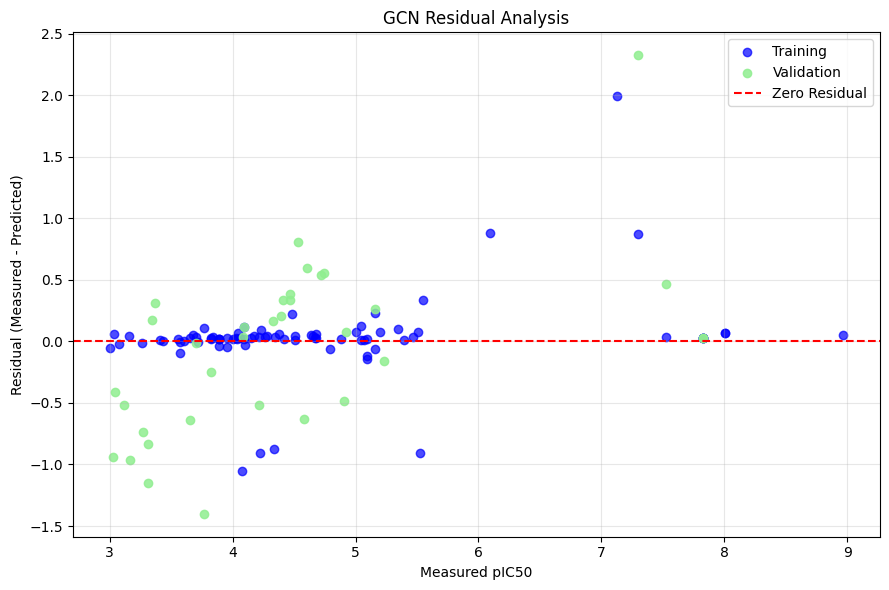


TOP 10 LARGEST VALIDATION ERRORS


,Smiles,Measured_pIC50,Predicted_pIC50,Residual,Absolute_Error
13,CC(NC(=O)C1CCCC1)C(=O)Nc1nnc(Cc2ccc([N+](=O)[O...,7.301030,4.976074,2.324956,2.324956
3,CC(C)(C)c1ccc(C(=O)CCC(=O)O)cc1,3.769551,5.170304,-1.400753,1.400753
32,Cc1cccc2c(=O)n(CC(=O)O)cnc12,3.309804,4.459943,-1.150139,1.150139
11,O=C(O)CCC(=O)c1ccccc1,3.167491,4.133113,-0.965622,0.965622
10,O=C(O)Cn1cc2ccccc2n1,3.031517,3.971985,-0.940468,0.940468
0,O=C(O)CCC(=O)c1ccc2ccccc2c1,3.309804,4.141653,-0.831849,0.831849
15,Cc1cc(C(=O)CN2CCCCC2)c(C)n1-c1ccc(F)cc1,4.535511,3.726351,0.809159,0.809159
4,O=C(O)CCn1nnc(-c2ccccc2)n1,3.275724,4.013582,-0.737858,0.737858
6,O=C(O)Cn1cnc2ccccc2c1=O,3.657577,4.298785,-0.641207,0.641207
2,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(c3ccc(Cl)cc3...,4.585027,5.213528,-0.628501,0.628501



Residual analysis berhasil!
Semua hasil tersimpan di: /data/Aliya


In [22]:

# ============================================================
# RESIDUAL ANALYSIS - GRAPHCONVMODEL
# USP5 DATASET - 1000 EPOCH
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD PREDICTION RESULTS
# ============================================================

folder = "/data/Aliya"

train_df = pd.read_csv(
    os.path.join(folder, "train_predictions.csv")
)

valid_df = pd.read_csv(
    os.path.join(folder, "validation_predictions.csv")
)

# ============================================================
# 2. CALCULATE RESIDUAL
# ============================================================

train_df["Residual"] = (
    train_df["Measured_pIC50"]
    - train_df["Predicted_pIC50"]
)

valid_df["Residual"] = (
    valid_df["Measured_pIC50"]
    - valid_df["Predicted_pIC50"]
)

train_df["Absolute_Error"] = train_df["Residual"].abs()
valid_df["Absolute_Error"] = valid_df["Residual"].abs()

print("=" * 60)
print("RESIDUAL ANALYSIS")
print("=" * 60)

print("\nTraining:")
print(train_df["Residual"].describe())

print("\nValidation:")
print(valid_df["Residual"].describe())

# ============================================================
# 3. RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    train_df["Measured_pIC50"],
    train_df["Residual"],
    color="blue",
    alpha=0.7,
    label="Training"
)

plt.scatter(
    valid_df["Measured_pIC50"],
    valid_df["Residual"],
    color="lightgreen",
    alpha=0.85,
    label="Validation"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    label="Zero Residual"
)

plt.xlabel("Measured pIC50")
plt.ylabel("Residual (Measured - Predicted)")
plt.title("GCN Residual Analysis")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(folder, "GCN_Residual_Plot.png"),
    dpi=300
)

plt.show()

# ============================================================
# 4. LARGEST PREDICTION ERRORS
# ============================================================

largest_errors = valid_df.sort_values(
    by="Absolute_Error",
    ascending=False
).head(10)

print("\nTOP 10 LARGEST VALIDATION ERRORS")

display(
    largest_errors[
        [
            "Smiles",
            "Measured_pIC50",
            "Predicted_pIC50",
            "Residual",
            "Absolute_Error"
        ]
    ]
)

# ============================================================
# 5. SAVE RESULTS
# ============================================================

train_df.to_csv(
    os.path.join(folder, "GCN_Train_Residuals.csv"),
    index=False
)

valid_df.to_csv(
    os.path.join(folder, "GCN_Validation_Residuals.csv"),
    index=False
)

largest_errors.to_csv(
    os.path.join(folder, "GCN_Top10_Validation_Errors.csv"),
    index=False
)

print("\nResidual analysis berhasil!")
print("Semua hasil tersimpan di:", folder)


EVALUATION BY pIC50 RANGE


,pIC50_Range,Number_of_Compounds,MAE
0,<4,13,0.6424
1,4-5,15,0.3866
2,5-6,2,0.2115
3,>6,4,0.7130


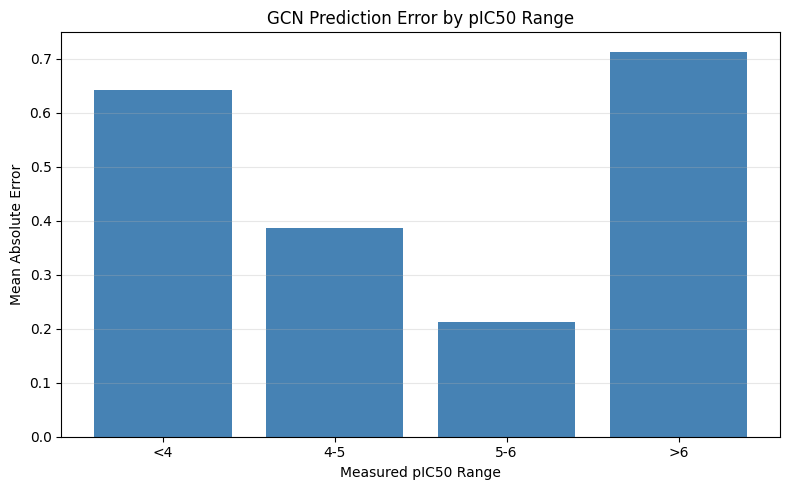

In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data validation
df = pd.read_csv(
    "/data/Aliya/GCN_Validation_Residuals.csv"
)

# Kelompok pIC50 berdasarkan nilai aktual
bins = [0, 4, 5, 6, 10]
labels = ["<4", "4-5", "5-6", ">6"]

df["pIC50_Range"] = pd.cut(
    df["Measured_pIC50"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Hitung jumlah data dan MAE
summary = (
    df.groupby("pIC50_Range", observed=False)
    .agg(
        Number_of_Compounds=("Absolute_Error", "count"),
        MAE=("Absolute_Error", "mean")
    )
    .reset_index()
)

print("EVALUATION BY pIC50 RANGE")
display(summary.round(4))

# Visualisasi MAE
plt.figure(figsize=(8, 5))

plt.bar(
    summary["pIC50_Range"].astype(str),
    summary["MAE"],
    color="steelblue"
)

plt.xlabel("Measured pIC50 Range")
plt.ylabel("Mean Absolute Error")
plt.title("GCN Prediction Error by pIC50 Range")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/data/Aliya/GCN_Error_by_pIC50_Range.png",
    dpi=300
)

plt.show()

summary.to_csv(
    "/data/Aliya/GCN_Error_by_pIC50_Range.csv",
    index=False
)


In [24]:

# ============================================================
# HYPERPARAMETER TUNING GRAPHCONVMODEL
# USP5 - 3 FOLD CROSS-VALIDATION
# ============================================================

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import deepchem as dc

from deepchem.models import GraphConvModel
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from itertools import product

# ============================================================
# 1. SETTINGS
# ============================================================

SEED = 42
EPOCHS = 100
N_FOLDS = 3

LEARNING_RATES = [0.0001, 0.0005, 0.001]
BATCH_SIZES = [8, 16, 32]

OUTPUT_DIR = "/data/Aliya"
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# 2. LOAD DATASET
# ============================================================

dataset_file = os.path.join(
    OUTPUT_DIR, "USP5_1.csv"
)

loader = dc.data.CSVLoader(
    tasks=["pIC50"],
    smiles_field="Smiles",
    featurizer=dc.feat.ConvMolFeaturizer()
)

dataset_tuning = loader.create_dataset(dataset_file)

print("Total molekul:", len(dataset_tuning))

# ============================================================
# 3. PREPARE CROSS-VALIDATION
# ============================================================

kf = KFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

splits = list(
    kf.split(np.arange(len(dataset_tuning)))
)

combinations = list(
    product(LEARNING_RATES, BATCH_SIZES)
)

results = []

print("Total kombinasi:", len(combinations))
print("Total training:", len(combinations) * N_FOLDS)

# ============================================================
# 4. HYPERPARAMETER TUNING
# ============================================================

for config_id, (lr, batch_size) in enumerate(
    combinations, start=1
):

    print("\n" + "=" * 60)
    print(f"CONFIGURATION {config_id}/{len(combinations)}")
    print(f"Learning rate: {lr}")
    print(f"Batch size   : {batch_size}")
    print("=" * 60)

    for fold, (train_idx, valid_idx) in enumerate(
        splits, start=1
    ):

        train_fold = dataset_tuning.select(train_idx)
        valid_fold = dataset_tuning.select(valid_idx)

        # Seed untuk setiap fold
        np.random.seed(SEED + fold)
        tf.random.set_seed(SEED + fold)

        # Bersihkan state model sebelumnya
        tf.keras.backend.clear_session()

        # Model baru untuk setiap pengujian
        model = GraphConvModel(
            n_tasks=1,
            batch_size=batch_size,
            mode="regression",
            learning_rate=lr,
            batch_normalize=False
        )

        print(f"\nFold {fold}/{N_FOLDS} - Training...")

        loss = model.fit(
            train_fold,
            nb_epoch=EPOCHS
        )

        y_true = np.asarray(
            valid_fold.y
        ).reshape(-1)

        y_pred = np.asarray(
            model.predict(valid_fold)
        ).reshape(-1)

        mae = mean_absolute_error(y_true, y_pred)

        rmse = np.sqrt(
            mean_squared_error(y_true, y_pred)
        )

        r2 = r2_score(y_true, y_pred)

        results.append({
            "Configuration": config_id,
            "Learning_Rate": lr,
            "Batch_Size": batch_size,
            "Fold": fold,
            "Epochs": EPOCHS,
            "Loss": float(loss),
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        print(f"MAE  : {mae:.4f}")
        print(f"RMSE : {rmse:.4f}")
        print(f"R2   : {r2:.4f}")

        # Simpan hasil setiap fold
        pd.DataFrame(results).to_csv(
            os.path.join(
                OUTPUT_DIR,
                "GCN_Hyperparameter_Tuning_Detail.csv"
            ),
            index=False
        )

        del model
        gc.collect()

# ============================================================
# 5. SUMMARY
# ============================================================

results_df = pd.DataFrame(results)

summary = (
    results_df.groupby(
        ["Configuration", "Learning_Rate", "Batch_Size"]
    )
    .agg(
        MAE_Mean=("MAE", "mean"),
        MAE_Std=("MAE", "std"),
        RMSE_Mean=("RMSE", "mean"),
        RMSE_Std=("RMSE", "std"),
        R2_Mean=("R2", "mean"),
        R2_Std=("R2", "std")
    )
    .reset_index()
)

# Ranking berdasarkan rata-rata MAE terkecil
summary = summary.sort_values(
    by="MAE_Mean",
    ascending=True
).reset_index(drop=True)

print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING RESULTS")
print("=" * 60)

display(summary.round(4))

# ============================================================
# 6. BEST CONFIGURATION
# ============================================================

best = summary.iloc[0]

print("\n" + "=" * 60)
print("BEST CONFIGURATION")
print("=" * 60)

print("Learning Rate :", best["Learning_Rate"])
print("Batch Size    :", int(best["Batch_Size"]))
print("Mean MAE      :", round(best["MAE_Mean"], 4))
print("Mean RMSE     :", round(best["RMSE_Mean"], 4))
print("Mean R2       :", round(best["R2_Mean"], 4))

# ============================================================
# 7. SAVE SUMMARY
# ============================================================

summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "GCN_Hyperparameter_Tuning_Summary.csv"
    ),
    index=False
)

print("\nHyperparameter tuning selesai!")
print("Hasil tersimpan di:", OUTPUT_DIR)


[05:03:30] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[05:03:30] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[05:03:30] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[05:03:30] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[05:03:30] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[05:03:30] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[05:03:30] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[05:03:30] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[05:03:30] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[05:03:30] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[05:03:30] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[05:03:30] DEPRECATIO

Total molekul: 118
Total kombinasi: 9
Total training: 27

CONFIGURATION 1/9
Learning rate: 0.0001
Batch size   : 8

Fold 1/3 - Training...
MAE  : 0.7410
RMSE : 1.1724
R2   : 0.2873

Fold 2/3 - Training...
MAE  : 0.7197
RMSE : 1.0160
R2   : 0.3981

Fold 3/3 - Training...
MAE  : 0.5368
RMSE : 0.7275
R2   : 0.6512

CONFIGURATION 2/9
Learning rate: 0.0001
Batch size   : 16

Fold 1/3 - Training...
MAE  : 0.8240
RMSE : 1.2399
R2   : 0.2028

Fold 2/3 - Training...
MAE  : 0.7172
RMSE : 1.0159
R2   : 0.3983

Fold 3/3 - Training...


MAE  : 0.5352
RMSE : 0.7060
R2   : 0.6715

CONFIGURATION 3/9
Learning rate: 0.0001
Batch size   : 32

Fold 1/3 - Training...
MAE  : 0.6856
RMSE : 1.0201
R2   : 0.4604

Fold 2/3 - Training...
MAE  : 0.8161
RMSE : 1.1484
R2   : 0.2311

Fold 3/3 - Training...
MAE  : 0.6413
RMSE : 0.8425
R2   : 0.5322

CONFIGURATION 4/9
Learning rate: 0.0005
Batch size   : 8

Fold 1/3 - Training...
MAE  : 0.6976
RMSE : 1.1452
R2   : 0.3200

Fold 2/3 - Training...
MAE  : 0.7132
RMSE : 1.0425
R2   : 0.3663

Fold 3/3 - Training...
MAE  : 0.4516
RMSE : 0.6725
R2   : 0.7019

CONFIGURATION 5/9
Learning rate: 0.0005
Batch size   : 16

Fold 1/3 - Training...
MAE  : 0.7270
RMSE : 1.1722
R2   : 0.2876

Fold 2/3 - Training...
MAE  : 0.6609
RMSE : 0.9550
R2   : 0.4683

Fold 3/3 - Training...


MAE  : 0.4990
RMSE : 0.7037
R2   : 0.6736

CONFIGURATION 6/9
Learning rate: 0.0005
Batch size   : 32

Fold 1/3 - Training...
MAE  : 0.6880
RMSE : 1.1269
R2   : 0.3415

Fold 2/3 - Training...
MAE  : 0.7451
RMSE : 1.0508
R2   : 0.3562

Fold 3/3 - Training...
MAE  : 0.4258
RMSE : 0.6249
R2   : 0.7427

CONFIGURATION 7/9
Learning rate: 0.001
Batch size   : 8

Fold 1/3 - Training...
MAE  : 0.7603
RMSE : 1.2583
R2   : 0.1790

Fold 2/3 - Training...
MAE  : 0.6480
RMSE : 1.0564
R2   : 0.3494

Fold 3/3 - Training...
MAE  : 0.4515
RMSE : 0.6843
R2   : 0.6914

CONFIGURATION 8/9
Learning rate: 0.001
Batch size   : 16

Fold 1/3 - Training...
MAE  : 0.6602
RMSE : 1.1497
R2   : 0.3146

Fold 2/3 - Training...
MAE  : 0.6976
RMSE : 1.0091
R2   : 0.4063

Fold 3/3 - Training...
MAE  : 0.5236
RMSE : 0.7697
R2   : 0.6096

CONFIGURATION 9/9
Learning rate: 0.001
Batch size   : 32

Fold 1/3 - Training...
MAE  : 0.7315
RMSE : 1.1172
R2   : 0.3527

Fold 2/3 - Training...
MAE  : 0.6853
RMSE : 1.0127
R2   : 0.4020


,Configuration,Learning_Rate,Batch_Size,MAE_Mean,MAE_Std,RMSE_Mean,RMSE_Std,R2_Mean,R2_Std
0,6,0.0005,32,0.6196,0.1702,0.9342,0.2706,0.4801,0.2275
1,7,0.0010,8,0.6199,0.1563,0.9996,0.2911,0.4066,0.2609
2,4,0.0005,8,0.6208,0.1467,0.9534,0.2486,0.4627,0.2084
3,8,0.0010,16,0.6271,0.0916,0.9762,0.1921,0.4435,0.1510
4,5,0.0005,16,0.6289,0.1173,0.9436,0.2344,0.4765,0.1932
5,9,0.0010,32,0.6435,0.1148,0.9569,0.1943,0.4644,0.1526
6,1,0.0001,8,0.6658,0.1122,0.9720,0.2257,0.4455,0.1865
7,2,0.0001,16,0.6921,0.1460,0.9873,0.2681,0.4242,0.2354
8,3,0.0001,32,0.7143,0.0909,1.0037,0.1536,0.4079,0.1573



BEST CONFIGURATION
Learning Rate : 0.0005
Batch Size    : 32
Mean MAE      : 0.6196
Mean RMSE     : 0.9342
Mean R2       : 0.4801

Hyperparameter tuning selesai!
Hasil tersimpan di: /data/Aliya


In [25]:

# ============================================================
# OPTIMIZED GRAPHCONVMODEL
# 5-FOLD CROSS-VALIDATION - 1000 EPOCH
# DATASET USP5
# ============================================================

import os

# Harus diatur sebelum TensorFlow diimport pada kernel baru
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import deepchem as dc

from deepchem.models import GraphConvModel
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# 1. SETTINGS
# ============================================================

SEED = 42
N_FOLDS = 5
EPOCHS = 1000

# Optimized Hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 0.0005

OUTPUT_DIR = "/data/Aliya"
DATASET_FILE = os.path.join(OUTPUT_DIR, "USP5_1.csv")

DETAIL_FILE = os.path.join(
    OUTPUT_DIR,
    "GCN_5Fold_Optimized_1000Epoch.csv"
)

SUMMARY_FILE = os.path.join(
    OUTPUT_DIR,
    "GCN_5Fold_Optimized_Summary.csv"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 65)
print("OPTIMIZED GRAPHCONVMODEL - 5 FOLD CROSS VALIDATION")
print("=" * 65)

print("Dataset       :", DATASET_FILE)
print("Learning Rate :", LEARNING_RATE)
print("Batch Size    :", BATCH_SIZE)
print("Epochs        :", EPOCHS)
print("Number Folds  :", N_FOLDS)
print("Random Seed   :", SEED)

# ============================================================
# 2. LOAD AND FEATURIZE DATASET
# ============================================================

print("\n" + "=" * 65)
print("LOAD AND FEATURIZE DATASET")
print("=" * 65)

loader = dc.data.CSVLoader(
    tasks=["pIC50"],
    smiles_field="Smiles",
    featurizer=dc.feat.ConvMolFeaturizer()
)

dataset = loader.create_dataset(DATASET_FILE)

print("Jumlah data :", len(dataset))
print("Shape y     :", dataset.y.shape)
print("Shape w     :", dataset.w.shape)

# ============================================================
# 3. PREPARE 5-FOLD CROSS-VALIDATION
# ============================================================

kf = KFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

splits = list(
    kf.split(np.arange(len(dataset)))
)

results_cv = []
all_predictions = []

# ============================================================
# 4. CROSS-VALIDATION TRAINING
# ============================================================

for fold, (train_idx, valid_idx) in enumerate(
    splits,
    start=1
):

    print("\n" + "=" * 65)
    print(f"FOLD {fold}/{N_FOLDS}")
    print("=" * 65)

    # --------------------------------------------------------
    # DATA SPLIT
    # --------------------------------------------------------

    train_fold = dataset.select(train_idx)
    valid_fold = dataset.select(valid_idx)

    print("Training data   :", len(train_fold))
    print("Validation data :", len(valid_fold))

    # --------------------------------------------------------
    # RANDOM SEED
    # --------------------------------------------------------

    np.random.seed(SEED + fold)
    tf.random.set_seed(SEED + fold)

    # Membersihkan state Keras antar-fold
    tf.keras.backend.clear_session()

    # --------------------------------------------------------
    # CREATE NEW MODEL
    # --------------------------------------------------------

    model_cv = GraphConvModel(
        n_tasks=1,
        batch_size=BATCH_SIZE,
        mode="regression",
        learning_rate=LEARNING_RATE,
        batch_normalize=False
    )

    # --------------------------------------------------------
    # TRAIN MODEL
    # --------------------------------------------------------

    print(f"\nMemulai training {EPOCHS} epoch...")

    loss = model_cv.fit(
        train_fold,
        nb_epoch=EPOCHS
    )

    print("Training selesai!")
    print(f"Final Loss: {loss:.6f}")

    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    y_true = np.asarray(
        valid_fold.y,
        dtype=np.float32
    ).reshape(-1)

    y_pred = np.asarray(
        model_cv.predict(valid_fold),
        dtype=np.float32
    ).reshape(-1)

    # --------------------------------------------------------
    # EVALUATION
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    results_cv.append({
        "Fold": fold,
        "Epochs": EPOCHS,
        "Learning_Rate": LEARNING_RATE,
        "Batch_Size": BATCH_SIZE,
        "Loss": float(loss),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2)
    })

    # Simpan prediksi validation setiap fold
    fold_predictions = pd.DataFrame({
        "Fold": fold,
        "SMILES": valid_fold.ids,
        "Measured_pIC50": y_true,
        "Predicted_pIC50": y_pred,
        "Residual": y_true - y_pred
    })

    all_predictions.append(fold_predictions)

    print("\nEVALUATION RESULTS")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    # --------------------------------------------------------
    # SAVE PROGRESS AFTER EACH FOLD
    # --------------------------------------------------------

    pd.DataFrame(results_cv).to_csv(
        DETAIL_FILE,
        index=False
    )

    pd.concat(
        all_predictions,
        ignore_index=True
    ).to_csv(
        os.path.join(
            OUTPUT_DIR,
            "GCN_Optimized_CV_Predictions.csv"
        ),
        index=False
    )

    print(f"Fold {fold} berhasil disimpan!")

    # --------------------------------------------------------
    # CLEAN MEMORY
    # --------------------------------------------------------

    del model_cv
    gc.collect()

# ============================================================
# 5. FINAL CROSS-VALIDATION RESULTS
# ============================================================

cv_df = pd.DataFrame(results_cv)

print("\n" + "=" * 65)
print("OPTIMIZED 5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 65)

display(
    cv_df[
        ["Fold", "Loss", "MAE", "RMSE", "R2"]
    ].round(4)
)

# ============================================================
# 6. MEAN AND STANDARD DEVIATION
# ============================================================

summary_cv = cv_df[
    ["MAE", "RMSE", "R2"]
].agg(["mean", "std"])

print("\n" + "=" * 65)
print("OPTIMIZED MODEL MEAN PERFORMANCE")
print("=" * 65)

display(summary_cv.round(4))

# ============================================================
# 7. COMPARE WITH ORIGINAL MODEL
# ============================================================

original_file = os.path.join(
    OUTPUT_DIR,
    "GCN_5Fold_CrossValidation_1000Epoch.csv"
)

if os.path.exists(original_file):

    original_df = pd.read_csv(original_file)

    metrics = ["MAE", "RMSE", "R2"]

    comparison = pd.DataFrame({
        "Metric": metrics,
        "Original_Mean": original_df[metrics].mean().values,
        "Optimized_Mean": cv_df[metrics].mean().values,
        "Original_Std": original_df[metrics].std().values,
        "Optimized_Std": cv_df[metrics].std().values
    })

    print("\n" + "=" * 65)
    print("ORIGINAL VS OPTIMIZED GRAPHCONVMODEL")
    print("=" * 65)

    display(comparison.round(4))

    comparison.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "GCN_Original_vs_Optimized.csv"
        ),
        index=False
    )

else:
    print("\nFile evaluasi original tidak ditemukan.")

# ============================================================
# 8. SAVE FINAL RESULTS
# ============================================================

cv_df.to_csv(
    DETAIL_FILE,
    index=False
)

summary_cv.to_csv(
    SUMMARY_FILE
)

print("\n" + "=" * 65)
print("OPTIMIZED CROSS-VALIDATION SELESAI!")
print("=" * 65)

print("Jumlah folds     :", N_FOLDS)
print("Epoch per fold   :", EPOCHS)
print("Learning rate    :", LEARNING_RATE)
print("Batch size       :", BATCH_SIZE)
print("Lokasi hasil     :", OUTPUT_DIR)


OPTIMIZED GRAPHCONVMODEL - 5 FOLD CROSS VALIDATION
Dataset       : /data/Aliya/USP5_1.csv
Learning Rate : 0.0005
Batch Size    : 32
Epochs        : 1000
Number Folds  : 5
Random Seed   : 42

LOAD AND FEATURIZE DATASET


[06:17:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[06:17:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[06:17:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[06:17:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[06:17:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[06:17:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[06:17:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[06:17:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[06:17:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[06:17:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[06:17:19] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[06:17:19] DEPRECATIO

Jumlah data : 118
Shape y     : (118, 1)
Shape w     : (118, 1)

FOLD 1/5
Training data   : 94
Validation data : 24

Memulai training 1000 epoch...
Training selesai!
Final Loss: 0.088139

EVALUATION RESULTS
MAE  : 0.4094
RMSE : 0.6353
R2   : 0.7348
Fold 1 berhasil disimpan!

FOLD 2/5
Training data   : 94
Validation data : 24

Memulai training 1000 epoch...
Training selesai!
Final Loss: 0.078390

EVALUATION RESULTS
MAE  : 0.5738
RMSE : 0.8789
R2   : 0.5925
Fold 2 berhasil disimpan!

FOLD 3/5
Training data   : 94
Validation data : 24

Memulai training 1000 epoch...
Training selesai!
Final Loss: 0.038734

EVALUATION RESULTS
MAE  : 0.7353
RMSE : 1.2914
R2   : 0.3070
Fold 3 berhasil disimpan!

FOLD 4/5
Training data   : 95
Validation data : 23

Memulai training 1000 epoch...
Training selesai!
Final Loss: 0.070640

EVALUATION RESULTS
MAE  : 0.5372
RMSE : 0.7788
R2   : -0.7131
Fold 4 berhasil disimpan!

FOLD 5/5
Training data   : 95
Validation data : 23

Memulai training 1000 epoch...
Trainin

,Fold,Loss,MAE,RMSE,R2
0,1,0.0881,0.4094,0.6353,0.7348
1,2,0.0784,0.5738,0.8789,0.5925
2,3,0.0387,0.7353,1.2914,0.3070
3,4,0.0706,0.5372,0.7788,-0.7131
4,5,0.1048,0.3577,0.6701,0.7772



OPTIMIZED MODEL MEAN PERFORMANCE


,MAE,RMSE,R2
mean,0.5227,0.8509,0.3397
std,0.1484,0.2642,0.6166



ORIGINAL VS OPTIMIZED GRAPHCONVMODEL


,Metric,Original_Mean,Optimized_Mean,Original_Std,Optimized_Std
0,MAE,0.5262,0.5227,0.1227,0.1484
1,RMSE,0.7509,0.8509,0.2409,0.2642
2,R2,0.4897,0.3397,0.4621,0.6166



OPTIMIZED CROSS-VALIDATION SELESAI!
Jumlah folds     : 5
Epoch per fold   : 1000
Learning rate    : 0.0005
Batch size       : 32
Lokasi hasil     : /data/Aliya


In [26]:

import pandas as pd

# ==================================================
# 1. LOAD STILBEN DATASET FROM GITHUB
# ==================================================

url = (
    "https://raw.githubusercontent.com/"
    "aliyarahmaazizah/USP5/main/"
    "stilben%20kurasi.csv"
)

stilben_df = pd.read_csv(url)

# ==================================================
# 2. DATASET INFORMATION
# ==================================================

print("=" * 55)
print("STILBEN DATASET")
print("=" * 55)

print("Jumlah senyawa:", len(stilben_df))
print("Jumlah kolom:", len(stilben_df.columns))
print("Nama kolom:", stilben_df.columns.tolist())

print("\nMissing values:")
print(stilben_df.isna().sum())

print("\nPreview dataset:")
display(stilben_df.head(10))

# ==================================================
# 3. SAVE DATASET LOCALLY
# ==================================================

stilben_df.to_csv(
    "/data/Aliya/stilben_kurasi.csv",
    index=False
)

print("\nDataset berhasil disimpan!")


STILBEN DATASET
Jumlah senyawa: 3336
Jumlah kolom: 3
Nama kolom: ['ChEMBL ID', 'SMILES', 'Smiles (RDKit Mol)']

Missing values:
ChEMBL ID             0
SMILES                0
Smiles (RDKit Mol)    0
dtype: int64

Preview dataset:


,ChEMBL ID,SMILES,Smiles (RDKit Mol)
0,CHEMBL246475,O=C(Nc1ccccc1)Nc1ccc(/C=C2\C(=O)Nc3ccccc32)cc1,O=C(Nc1ccccc1)Nc1ccc(/C=C2\C(=O)Nc3ccccc32)cc1
1,CHEMBL533057,COc1ccc2nccc([C@@H](O)CN3CCC(NC(=O)C(=Cc4ccc(C...,COc1ccc2nccc([C@@H](O)CN3CCC(NC(=O)C(=Cc4ccc(C...
2,CHEMBL93652,CCN(CC)CCCCN1c2ccccc2C=Cc2ccccc21,CCN(CC)CCCCN1c2ccccc2C=Cc2ccccc21
3,CHEMBL328738,CCCCC(=O)N(Cc1ccc2c(c1)Oc1ccccc1C=C2c1nnn[nH]1...,CCCCC(=O)N(Cc1ccc2c(c1)Oc1ccccc1C=C2c1nnn[nH]1...
4,CHEMBL435268,COc1cc2c(cc1OC)C1=C(c3ccccc3OC)C(=O)C(=O)N1CC2,COc1cc2c(cc1OC)C1=C(c3ccccc3OC)C(=O)C(=O)N1CC2
5,CHEMBL397687,O=C(O)c1cccc(C2=C(c3cc(Br)ccc3OCc3ccccc3)CCC2)c1,O=C(O)c1cccc(C2=C(c3cc(Br)ccc3OCc3ccccc3)CCC2)c1
6,CHEMBL127674,Cc1ccc(C2=C(c3ccc(S(C)(=O)=O)cc3)CCC2)cc1,Cc1ccc(C2=C(c3ccc(S(C)(=O)=O)cc3)CCC2)cc1
7,CHEMBL374173,COC(=O)C1=C(c2ccc(O)cc2)C2OC1C(c1ccccc1)=C2c1c...,COC(=O)C1=C(c2ccc(O)cc2)C2OC1C(c1ccccc1)=C2c1c...
8,CHEMBL391100,COc1ccc(/C=C/c2cc(OC)c(CCCCCCCCCCCCCCCCO)c(OC)...,COc1ccc(/C=C/c2cc(OC)c(CCCCCCCCCCCCCCCCO)c(OC)...
9,CHEMBL75720,CCC[C@@H]1C(c2ccc(O)cc2)=C(CC)c2ccc(O)cc21,CCC[C@@H]1C(c2ccc(O)cc2)=C(CC)c2ccc(O)cc21



Dataset berhasil disimpan!


In [27]:

# ============================================================
# VALIDASI DATASET STILBEN
# ============================================================

import pandas as pd
from rdkit import Chem

# 1. Load dataset
df = pd.read_csv("/data/Aliya/stilben_kurasi.csv")

# 2. Validasi SMILES
df["RDKit_Mol"] = df["SMILES"].apply(
    Chem.MolFromSmiles
)

df["Valid_SMILES"] = df["RDKit_Mol"].apply(
    lambda mol: mol is not None
)

# 3. Canonical SMILES
df["Canonical_SMILES"] = df["RDKit_Mol"].apply(
    lambda mol: (
        Chem.MolToSmiles(mol, canonical=True)
        if mol is not None
        else None
    )
)

# 4. Periksa duplikasi
duplicate_smiles = df["Canonical_SMILES"].duplicated(
    keep=False
).sum()

duplicate_chembl = df["ChEMBL ID"].duplicated(
    keep=False
).sum()

print("=" * 55)
print("STILBEN DATA VALIDATION")
print("=" * 55)

print("Total senyawa:", len(df))
print("SMILES valid:", df["Valid_SMILES"].sum())
print("SMILES tidak valid:", (~df["Valid_SMILES"]).sum())
print("Baris dengan canonical SMILES duplikat:", duplicate_smiles)
print("Baris dengan ChEMBL ID duplikat:", duplicate_chembl)

# 5. Simpan hasil pemeriksaan
df.drop(columns=["RDKit_Mol"]).to_csv(
    "/data/Aliya/stilben_validation.csv",
    index=False
)

print("\nValidasi selesai!")
display(df[
    ["ChEMBL ID", "SMILES", "Canonical_SMILES", "Valid_SMILES"]
].head(10))


STILBEN DATA VALIDATION
Total senyawa: 3336
SMILES valid: 3336
SMILES tidak valid: 0
Baris dengan canonical SMILES duplikat: 0
Baris dengan ChEMBL ID duplikat: 0

Validasi selesai!


,ChEMBL ID,SMILES,Canonical_SMILES,Valid_SMILES
0,CHEMBL246475,O=C(Nc1ccccc1)Nc1ccc(/C=C2\C(=O)Nc3ccccc32)cc1,O=C(Nc1ccccc1)Nc1ccc(/C=C2\C(=O)Nc3ccccc32)cc1,True
1,CHEMBL533057,COc1ccc2nccc([C@@H](O)CN3CCC(NC(=O)C(=Cc4ccc(C...,COc1ccc2nccc([C@@H](O)CN3CCC(NC(=O)C(=Cc4ccc(C...,True
2,CHEMBL93652,CCN(CC)CCCCN1c2ccccc2C=Cc2ccccc21,CCN(CC)CCCCN1c2ccccc2C=Cc2ccccc21,True
3,CHEMBL328738,CCCCC(=O)N(Cc1ccc2c(c1)Oc1ccccc1C=C2c1nnn[nH]1...,CCCCC(=O)N(Cc1ccc2c(c1)Oc1ccccc1C=C2c1nnn[nH]1...,True
4,CHEMBL435268,COc1cc2c(cc1OC)C1=C(c3ccccc3OC)C(=O)C(=O)N1CC2,COc1cc2c(cc1OC)C1=C(c3ccccc3OC)C(=O)C(=O)N1CC2,True
5,CHEMBL397687,O=C(O)c1cccc(C2=C(c3cc(Br)ccc3OCc3ccccc3)CCC2)c1,O=C(O)c1cccc(C2=C(c3cc(Br)ccc3OCc3ccccc3)CCC2)c1,True
6,CHEMBL127674,Cc1ccc(C2=C(c3ccc(S(C)(=O)=O)cc3)CCC2)cc1,Cc1ccc(C2=C(c3ccc(S(C)(=O)=O)cc3)CCC2)cc1,True
7,CHEMBL374173,COC(=O)C1=C(c2ccc(O)cc2)C2OC1C(c1ccccc1)=C2c1c...,COC(=O)C1=C(c2ccc(O)cc2)C2OC1C(c1ccccc1)=C2c1c...,True
8,CHEMBL391100,COc1ccc(/C=C/c2cc(OC)c(CCCCCCCCCCCCCCCCO)c(OC)...,COc1ccc(/C=C/c2cc(OC)c(CCCCCCCCCCCCCCCCO)c(OC)...,True
9,CHEMBL75720,CCC[C@@H]1C(c2ccc(O)cc2)=C(CC)c2ccc(O)cc21,CCC[C@@H]1C(c2ccc(O)cc2)=C(CC)c2ccc(O)cc21,True


In [28]:

# ============================================================
# LOAD TRAINED GRAPHCONVMODEL
# USP5 - 1000 EPOCH
# ============================================================

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import tensorflow as tf
import deepchem as dc

from deepchem.models import GraphConvModel

# Lokasi checkpoint permanen
MODEL_DIR = "/data/Aliya/graphconv_saved_model"

# Pastikan folder tersedia
if not os.path.isdir(MODEL_DIR):
    raise FileNotFoundError(
        f"Folder checkpoint tidak ditemukan: {MODEL_DIR}"
    )

print("Isi folder checkpoint:")
print(os.listdir(MODEL_DIR))

# Membuat arsitektur model yang sama
graph_conv_stilben = GraphConvModel(
    n_tasks=1,
    batch_size=10,
    mode="regression",
    learning_rate=0.001,
    batch_normalize=False,
    model_dir=MODEL_DIR
)

# Memulihkan bobot hasil training
graph_conv_stilben.restore()

print("\nCheckpoint berhasil dimuat!")
print("Model:", type(graph_conv_stilben).__name__)
print("Lokasi:", graph_conv_stilben.model_dir)


Isi folder checkpoint:
['ckpt-8.data-00000-of-00001', 'checkpoint', 'ckpt-12.data-00000-of-00001', 'ckpt-10.data-00000-of-00001', 'ckpt-11.index', 'ckpt-8.index', 'ckpt-10.index', 'ckpt-12.index', 'ckpt-11.data-00000-of-00001', 'ckpt-9.data-00000-of-00001', 'ckpt-9.index']

Checkpoint berhasil dimuat!
Model: GraphConvModel
Lokasi: /data/Aliya/graphconv_saved_model


In [29]:

# ============================================================
# VERIFY RESTORED GRAPHCONVMODEL
# ============================================================

import numpy as np
import pandas as pd
import deepchem as dc
from rdkit import Chem

# 1. Load hasil prediksi lama
old_predictions = pd.read_csv(
    "/data/Aliya/validation_predictions.csv"
)

# 2. Ambil 5 senyawa untuk pengujian
sample = old_predictions.head(5).copy()

print("Jumlah sampel:", len(sample))

# 3. Konversi SMILES ke molekul RDKit
mols = [
    Chem.MolFromSmiles(s)
    for s in sample["Smiles"]
]

if any(mol is None for mol in mols):
    raise ValueError("Terdapat SMILES tidak valid!")

# 4. Featurization
featurizer = dc.feat.ConvMolFeaturizer()
features = featurizer.featurize(mols)

# 5. Prediksi dengan model yang dipulihkan
new_predictions = graph_conv_stilben.predict_on_batch(
    features
)

new_predictions = np.asarray(
    new_predictions
).reshape(-1)

# 6. Bandingkan prediksi
sample["Restored_Prediction"] = new_predictions

sample["Difference"] = abs(
    sample["Predicted_pIC50"]
    - sample["Restored_Prediction"]
)

print("\nCHECKPOINT VERIFICATION")

display(
    sample[
        [
            "Smiles",
            "Predicted_pIC50",
            "Restored_Prediction",
            "Difference"
        ]
    ]
)

print("\nMaximum Difference:", sample["Difference"].max())

if np.allclose(
    sample["Predicted_pIC50"],
    sample["Restored_Prediction"],
    rtol=1e-4,
    atol=1e-4
):
    print("VERIFIKASI BERHASIL: Prediksi model konsisten!")
else:
    print("PERINGATAN: Prediksi model berbeda. Periksa checkpoint!")


Jumlah sampel: 5


[03:59:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:59:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:59:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:59:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:59:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:59:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:59:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:59:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:59:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:59:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:59:51] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[03:59:51] DEPRECATIO


CHECKPOINT VERIFICATION


,Smiles,Predicted_pIC50,Restored_Prediction,Difference
0,O=C(O)CCC(=O)c1ccc2ccccc2c1,4.141653,4.141653,6.091309e-08
1,O=C(O)CNC(=O)c1cccc(S(=O)(=O)N2CCC(c3ccccc3)CC...,4.046752,4.046752,2.398682e-08
2,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(c3ccc(Cl)cc3...,5.213528,5.213529,6.331177e-07
3,CC(C)(C)c1ccc(C(=O)CCC(=O)O)cc1,5.170304,5.170303,6.552734e-07
4,O=C(O)CCn1nnc(-c2ccccc2)n1,4.013582,4.013582,4.722290e-08



Maximum Difference: 6.552734372888835e-07
VERIFIKASI BERHASIL: Prediksi model konsisten!


In [30]:

# ============================================================
# PREDIKSI pIC50 DATASET STILBEN
# GRAPHCONVMODEL USP5 - 1000 EPOCH
# ============================================================

import os
import numpy as np
import pandas as pd
import deepchem as dc

from rdkit import Chem

# ============================================================
# 1. SETTINGS
# ============================================================

DATA_FILE = "/data/Aliya/stilben_kurasi.csv"
OUTPUT_FILE = "/data/Aliya/stilben_predicted_pIC50.csv"

BATCH_SIZE_PREDICTION = 100

# ============================================================
# 2. LOAD DATASET
# ============================================================

stilben_df = pd.read_csv(DATA_FILE)

print("=" * 60)
print("STILBEN pIC50 PREDICTION")
print("=" * 60)

print("Jumlah senyawa:", len(stilben_df))

# ============================================================
# 3. FEATURIZER
# ============================================================

featurizer = dc.feat.ConvMolFeaturizer()

all_predictions = []

# ============================================================
# 4. BATCH PREDICTION
# ============================================================

for start in range(
    0,
    len(stilben_df),
    BATCH_SIZE_PREDICTION
):

    end = min(
        start + BATCH_SIZE_PREDICTION,
        len(stilben_df)
    )

    batch = stilben_df.iloc[start:end]

    smiles_batch = batch["SMILES"].tolist()

    mols = [
        Chem.MolFromSmiles(s)
        for s in smiles_batch
    ]

    if any(mol is None for mol in mols):
        raise ValueError(
            f"SMILES tidak valid pada baris {start}-{end}"
        )

    # Featurization
    x = featurizer.featurize(mols)

    if len(x) != len(mols):
        raise ValueError(
            f"Featurization gagal pada batch {start}-{end}"
        )

    # Prediction
    predictions = graph_conv_stilben.predict_on_batch(x)

    predictions = np.asarray(
        predictions
    ).reshape(-1)

    if len(predictions) != len(batch):
        raise ValueError("Jumlah prediksi tidak sesuai!")

    all_predictions.extend(predictions.tolist())

    print(
        f"Prediksi selesai: {end}/{len(stilben_df)} senyawa"
    )

# ============================================================
# 5. SAVE RESULTS
# ============================================================

result_stilben = stilben_df[
    ["ChEMBL ID", "SMILES"]
].copy()

result_stilben["Predicted_pIC50"] = all_predictions

result_stilben.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\n" + "=" * 60)
print("PREDIKSI STILBEN SELESAI!")
print("=" * 60)

print("Total prediksi:", len(result_stilben))
print("File tersimpan:", OUTPUT_FILE)

display(result_stilben.head(10))


STILBEN pIC50 PREDICTION
Jumlah senyawa: 3336


[04:02:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:17] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:17] DEPRECATIO

Prediksi selesai: 100/3336 senyawa


[04:02:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:18] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:18] DEPRECATIO

Prediksi selesai: 200/3336 senyawa


...

Prediksi selesai: 3200/3336 senyawa


[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATIO

Prediksi selesai: 3300/3336 senyawa
Prediksi selesai: 3336/3336 senyawa

PREDIKSI STILBEN SELESAI!
Total prediksi: 3336
File tersimpan: /data/Aliya/stilben_predicted_pIC50.csv


[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:02:27] DEPRECATIO

,ChEMBL ID,SMILES,Predicted_pIC50
0,CHEMBL246475,O=C(Nc1ccccc1)Nc1ccc(/C=C2\C(=O)Nc3ccccc32)cc1,6.114724
1,CHEMBL533057,COc1ccc2nccc([C@@H](O)CN3CCC(NC(=O)C(=Cc4ccc(C...,4.433845
2,CHEMBL93652,CCN(CC)CCCCN1c2ccccc2C=Cc2ccccc21,4.956101
3,CHEMBL328738,CCCCC(=O)N(Cc1ccc2c(c1)Oc1ccccc1C=C2c1nnn[nH]1...,5.239676
4,CHEMBL435268,COc1cc2c(cc1OC)C1=C(c3ccccc3OC)C(=O)C(=O)N1CC2,4.538930
5,CHEMBL397687,O=C(O)c1cccc(C2=C(c3cc(Br)ccc3OCc3ccccc3)CCC2)c1,5.614064
6,CHEMBL127674,Cc1ccc(C2=C(c3ccc(S(C)(=O)=O)cc3)CCC2)cc1,5.755997
7,CHEMBL374173,COC(=O)C1=C(c2ccc(O)cc2)C2OC1C(c1ccccc1)=C2c1c...,4.997332
8,CHEMBL391100,COc1ccc(/C=C/c2cc(OC)c(CCCCCCCCCCCCCCCCO)c(OC)...,5.092355
9,CHEMBL75720,CCC[C@@H]1C(c2ccc(O)cc2)=C(CC)c2ccc(O)cc21,4.789248


In [31]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "/data/Aliya/stilben_predicted_pIC50.csv"
)

print("=" * 55)
print("VERIFIKASI HASIL PREDIKSI STILBEN")
print("=" * 55)

print("Jumlah senyawa:", len(df))
print("Jumlah prediksi:", df["Predicted_pIC50"].notna().sum())
print("Prediksi tidak valid:",
      (~np.isfinite(df["Predicted_pIC50"])).sum())

print("\nStatistik prediksi:")
print(df["Predicted_pIC50"].describe())

VERIFIKASI HASIL PREDIKSI STILBEN
Jumlah senyawa: 3336
Jumlah prediksi: 3336
Prediksi tidak valid: 0

Statistik prediksi:
count    3336.000000
mean        5.013452
std         0.801422
min         2.699464
25%         4.456418
50%         4.928930
75%         5.512388
max         8.021586
Name: Predicted_pIC50, dtype: float64


In [32]:
import numpy as np
import pandas as pd

df = pd.read_csv(
    "/data/Aliya/stilben_predicted_pIC50.csv"
)

predicted_pIC50 = df["Predicted_pIC50"].to_numpy(
    dtype=np.float32
).reshape(-1, 1)

print("Jumlah senyawa:", len(predicted_pIC50))

predicted_pIC50

Jumlah senyawa: 3336


array([[6.114724 ],
       [4.4338446],
       [4.9561014],
       ...,
       [6.4004297],
       [4.663995 ],
       [3.6156192]], dtype=float32)

Total senyawa: 3336


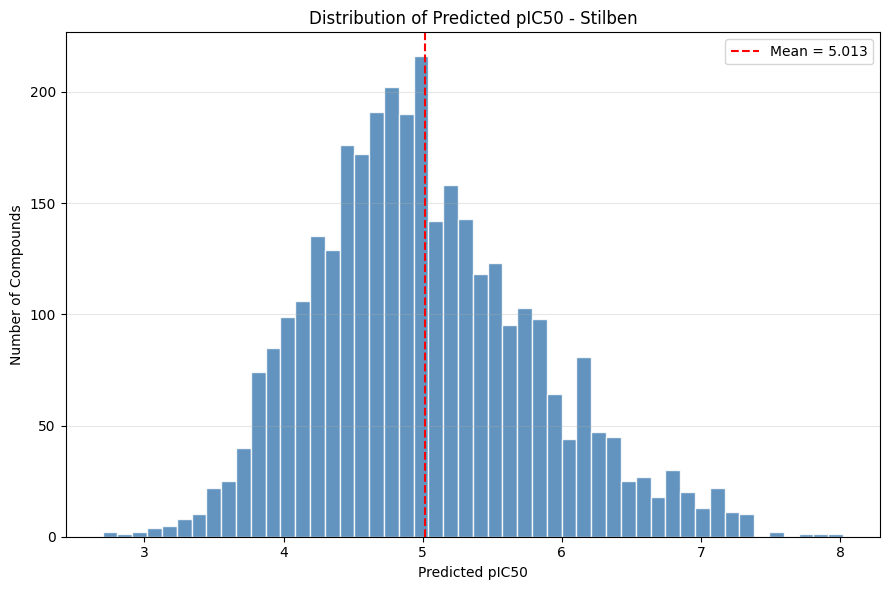


TOP 20 STILBEN COMPOUNDS


,Rank,ChEMBL ID,Predicted_pIC50
2830,1,CHEMBL192030,8.021586
2525,2,CHEMBL190498,7.849569
156,3,CHEMBL192908,7.794337
2325,4,CHEMBL87147,7.588780
2781,5,CHEMBL73321,7.588780
1975,6,CHEMBL39344,7.366441
2782,7,CHEMBL415449,7.366441
240,8,CHEMBL75468,7.363832
1984,9,CHEMBL21518,7.348150
407,10,CHEMBL472172,7.324203



Analisis berhasil!
Histogram dan Top 20 berhasil disimpan.


In [33]:

# ============================================================
# ANALISIS PREDIKSI pIC50 - 3336 SENYAWA STILBEN
# HISTOGRAM DAN TOP 20 COMPOUNDS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATASET HASIL PREDIKSI
df = pd.read_csv(
    "/data/Aliya/stilben_predicted_pIC50.csv"
)

print("Total senyawa:", len(df))

# 2. HISTOGRAM PREDIKSI pIC50
plt.figure(figsize=(9, 6))

plt.hist(
    df["Predicted_pIC50"],
    bins=50,
    color="steelblue",
    edgecolor="white",
    alpha=0.85
)

plt.axvline(
    df["Predicted_pIC50"].mean(),
    color="red",
    linestyle="--",
    label=f'Mean = {df["Predicted_pIC50"].mean():.3f}'
)

plt.xlabel("Predicted pIC50")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Predicted pIC50 - Stilben")

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/data/Aliya/Stilben_pIC50_Histogram.png",
    dpi=300
)

plt.show()

# 3. TOP 20 SENYAWA
top20 = df.sort_values(
    by="Predicted_pIC50",
    ascending=False
).head(20).copy()

top20.insert(
    0,
    "Rank",
    range(1, 21)
)

print("\n" + "=" * 55)
print("TOP 20 STILBEN COMPOUNDS")
print("=" * 55)

display(
    top20[
        ["Rank", "ChEMBL ID", "Predicted_pIC50"]
    ]
)

# 4. SIMPAN HASIL TOP 20
top20.to_csv(
    "/data/Aliya/Stilben_Top20_pIC50.csv",
    index=False
)

print("\nAnalisis berhasil!")
print("Histogram dan Top 20 berhasil disimpan.")


In [34]:

# ============================================================
# MOLECULAR SIMILARITY ANALYSIS
# STILBEN VS USP5 TRAINING DATASET
# MORGAN FINGERPRINT + TANIMOTO SIMILARITY
# ============================================================

import os
import numpy as np
import pandas as pd
import deepchem as dc

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

# ============================================================
# 1. SETTINGS
# ============================================================

OUTPUT_DIR = "/data/Aliya"

USP5_FILE = os.path.join(OUTPUT_DIR, "USP5_1.csv")
STILBEN_FILE = os.path.join(
    OUTPUT_DIR, "stilben_predicted_pIC50.csv"
)
TRAIN_PREDICTIONS_FILE = os.path.join(
    OUTPUT_DIR, "train_predictions.csv"
)

RADIUS = 2
N_BITS = 2048
SEED = 42

# ============================================================
# 2. LOAD DATASETS
# ============================================================

usp5_df = pd.read_csv(USP5_FILE)
stilben_df = pd.read_csv(STILBEN_FILE)
train_predictions = pd.read_csv(
    TRAIN_PREDICTIONS_FILE
)

print("=" * 60)
print("MOLECULAR SIMILARITY ANALYSIS")
print("=" * 60)

print("USP5 total:", len(usp5_df))
print("Stilben total:", len(stilben_df))

# ============================================================
# 3. RECONSTRUCT ORIGINAL TRAINING SPLIT
# ============================================================

loader = dc.data.CSVLoader(
    tasks=["pIC50"],
    smiles_field="Smiles",
    featurizer=dc.feat.ConvMolFeaturizer()
)

dataset = loader.create_dataset(USP5_FILE)

splitter = dc.splits.RandomSplitter()

train, valid, test = splitter.train_valid_test_split(
    dataset,
    frac_train=0.70,
    frac_valid=0.29,
    frac_test=0.01,
    seed=SEED
)

train_smiles = list(train.ids)

# Verifikasi kecocokan dengan training sebelumnya
saved_train_smiles = train_predictions["Smiles"].tolist()

if (
    len(train_smiles) != len(saved_train_smiles)
    or set(train_smiles) != set(saved_train_smiles)
):
    raise ValueError(
        "Training split tidak cocok dengan hasil sebelumnya. "
        "Periksa dataset dan pembagian training."
    )

print("Training set berhasil diverifikasi!")
print("Jumlah training compounds:", len(train_smiles))

# ============================================================
# 4. PREPARE MORGAN FINGERPRINT
# ============================================================

generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=RADIUS,
    fpSize=N_BITS
)

train_mols = [
    Chem.MolFromSmiles(s)
    for s in train_smiles
]

if any(mol is None for mol in train_mols):
    raise ValueError("Ada SMILES USP5 yang tidak valid!")

train_fps = [
    generator.GetFingerprint(mol)
    for mol in train_mols
]

# ============================================================
# 5. STILBEN SIMILARITY CALCULATION
# ============================================================

results = []

for idx, row in stilben_df.iterrows():

    mol = Chem.MolFromSmiles(row["SMILES"])

    if mol is None:
        raise ValueError(
            f"SMILES stilben tidak valid pada baris {idx}"
        )

    fp = generator.GetFingerprint(mol)

    similarities = DataStructs.BulkTanimotoSimilarity(
        fp,
        train_fps
    )

    best_idx = int(np.argmax(similarities))
    max_similarity = float(similarities[best_idx])

    results.append({
        "ChEMBL ID": row["ChEMBL ID"],
        "SMILES": row["SMILES"],
        "Predicted_pIC50": row["Predicted_pIC50"],
        "Max_Tanimoto_Similarity": max_similarity,
        "Nearest_USP5_SMILES": train_smiles[best_idx]
    })

    if (idx + 1) % 200 == 0:
        print(
            f"Similarity selesai: "
            f"{idx + 1}/{len(stilben_df)}"
        )

# ============================================================
# 6. SAVE FULL RESULTS
# ============================================================

similarity_df = pd.DataFrame(results)

similarity_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Stilben_USP5_Molecular_Similarity.csv"
    ),
    index=False
)

print("\nSimilarity calculation berhasil!")

# ============================================================
# 7. SUMMARY
# ============================================================

print("\nSIMILARITY STATISTICS")

display(
    similarity_df["Max_Tanimoto_Similarity"]
    .describe()
    .round(4)
)

# ============================================================
# 8. TOP 20 PREDICTED pIC50 WITH SIMILARITY
# ============================================================

top20_similarity = similarity_df.sort_values(
    by="Predicted_pIC50",
    ascending=False
).head(20).copy()

top20_similarity.insert(
    0,
    "Rank",
    range(1, 21)
)

print("\nTOP 20 STILBEN - pIC50 AND SIMILARITY")

display(
    top20_similarity[
        [
            "Rank",
            "ChEMBL ID",
            "Predicted_pIC50",
            "Max_Tanimoto_Similarity",
            "Nearest_USP5_SMILES"
        ]
    ]
)

top20_similarity.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Stilben_Top20_With_Similarity.csv"
    ),
    index=False
)

print("\nSemua hasil berhasil disimpan!")


MOLECULAR SIMILARITY ANALYSIS
USP5 total: 118
Stilben total: 3336


[04:38:57] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:38:57] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:38:57] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:38:57] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:38:57] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:38:57] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:38:57] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:38:57] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:38:57] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:38:57] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:38:57] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[04:38:57] DEPRECATIO

Training set berhasil diverifikasi!
Jumlah training compounds: 82
Similarity selesai: 200/3336
Similarity selesai: 400/3336
Similarity selesai: 600/3336
Similarity selesai: 800/3336
Similarity selesai: 1000/3336
Similarity selesai: 1200/3336
Similarity selesai: 1400/3336
Similarity selesai: 1600/3336
Similarity selesai: 1800/3336
Similarity selesai: 2000/3336
Similarity selesai: 2200/3336
Similarity selesai: 2400/3336
Similarity selesai: 2600/3336
Similarity selesai: 2800/3336
Similarity selesai: 3000/3336
Similarity selesai: 3200/3336

Similarity calculation berhasil!

SIMILARITY STATISTICS


count    3336.0000
mean        0.1963
std         0.0390
min         0.0672
25%         0.1695
50%         0.1930
75%         0.2182
max         0.4028
Name: Max_Tanimoto_Similarity, dtype: float64


TOP 20 STILBEN - pIC50 AND SIMILARITY


,Rank,ChEMBL ID,Predicted_pIC50,Max_Tanimoto_Similarity,Nearest_USP5_SMILES
2830,1,CHEMBL192030,8.021586,0.177419,COc1cc2ncn(CC(=O)O)c(=O)c2cc1OC
2525,2,CHEMBL190498,7.849569,0.256098,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(c3cccc(F)c3)...
156,3,CHEMBL192908,7.794337,0.253165,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(c3ccc(F)c(F)...
2325,4,CHEMBL87147,7.588780,0.203390,O=C(O)CCC(=O)c1ccc2c(c1)CCC2
2781,5,CHEMBL73321,7.588780,0.203390,O=C(O)CCC(=O)c1ccc2c(c1)CCC2
1975,6,CHEMBL39344,7.366441,0.203390,O=C(O)CCC(=O)c1ccc2c(c1)CCC2
2782,7,CHEMBL415449,7.366441,0.203390,O=C(O)CCC(=O)c1ccc2c(c1)CCC2
240,8,CHEMBL75468,7.363832,0.203390,O=C(O)CCC(=O)c1ccc2c(c1)CCC2
1984,9,CHEMBL21518,7.348150,0.203390,O=C(O)CCC(=O)c1ccc2c(c1)CCC2
407,10,CHEMBL472172,7.324203,0.187500,O=C(O)CCC(=O)c1ccc2c(c1)CCC2



Semua hasil berhasil disimpan!
